In [1]:
import pandas as pd, numpy as np, warnings, os
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

COLORS = {'primary': '#2962FF', 'secondary': '#FF6D00', 'accent': '#00C853',
          'danger': '#D50000', 'purple': '#AA00FF', 'teal': '#00BFA5'}
CAT_PALETTE = list(COLORS.values())

plt.rcParams.update({'figure.figsize': (14, 6), 'figure.dpi': 100,
                     'font.size': 10, 'axes.titlesize': 14, 'axes.labelsize': 11})

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


In [2]:
df = pd.read_csv("amazon_sales_dataset.csv")
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [3]:
print(df.dtypes)
print(f'\n✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

order_id              int64
order_date           object
product_id            int64
product_category     object
price               float64
discount_percent      int64
quantity_sold         int64
customer_region      object
payment_method       object
rating              float64
review_count          int64
discounted_price    float64
total_revenue       float64
dtype: object

✅ Dataset loaded: 50,000 rows × 13 columns


In [4]:
# ========================================
# DATA QUALITY ASSESSMENT
# ========================================
quality = pd.DataFrame({
    'Dtype': df.dtypes, 'Non-Null': df.notna().sum(),
    'Null %': (df.isna().mean() * 100).round(2),
    'Unique': df.nunique(), 'Sample': df.iloc[0]
})

print(f'🔍 Missing Values: {df.isna().sum().sum()} | Duplicates: {df.duplicated().sum()}')
print(f'✅ Data Quality Score: {((1 - df.isna().mean().mean()) * 100):.1f}%')
print('=' * 60)
quality

🔍 Missing Values: 0 | Duplicates: 0
✅ Data Quality Score: 100.0%


,Dtype,Non-Null,Null %,Unique,Sample
order_id,int64,50000,0.0,50000,1
order_date,object,50000,0.0,730,2022-04-13
product_id,int64,50000,0.0,4000,2637
product_category,object,50000,0.0,6,Books
price,float64,50000,0.0,31465,128.75
discount_percent,int64,50000,0.0,6,10
quantity_sold,int64,50000,0.0,5,4
customer_region,object,50000,0.0,4,North America
payment_method,object,50000,0.0,5,UPI
rating,float64,50000,0.0,41,3.5


In [5]:
# -----------------------
# Remove Duplicates 
# -----------------------
df.drop_duplicates(subset=["product_id","product_category"], inplace=True)
df[["product_id","product_category"]].duplicated().sum()

np.int64(0)

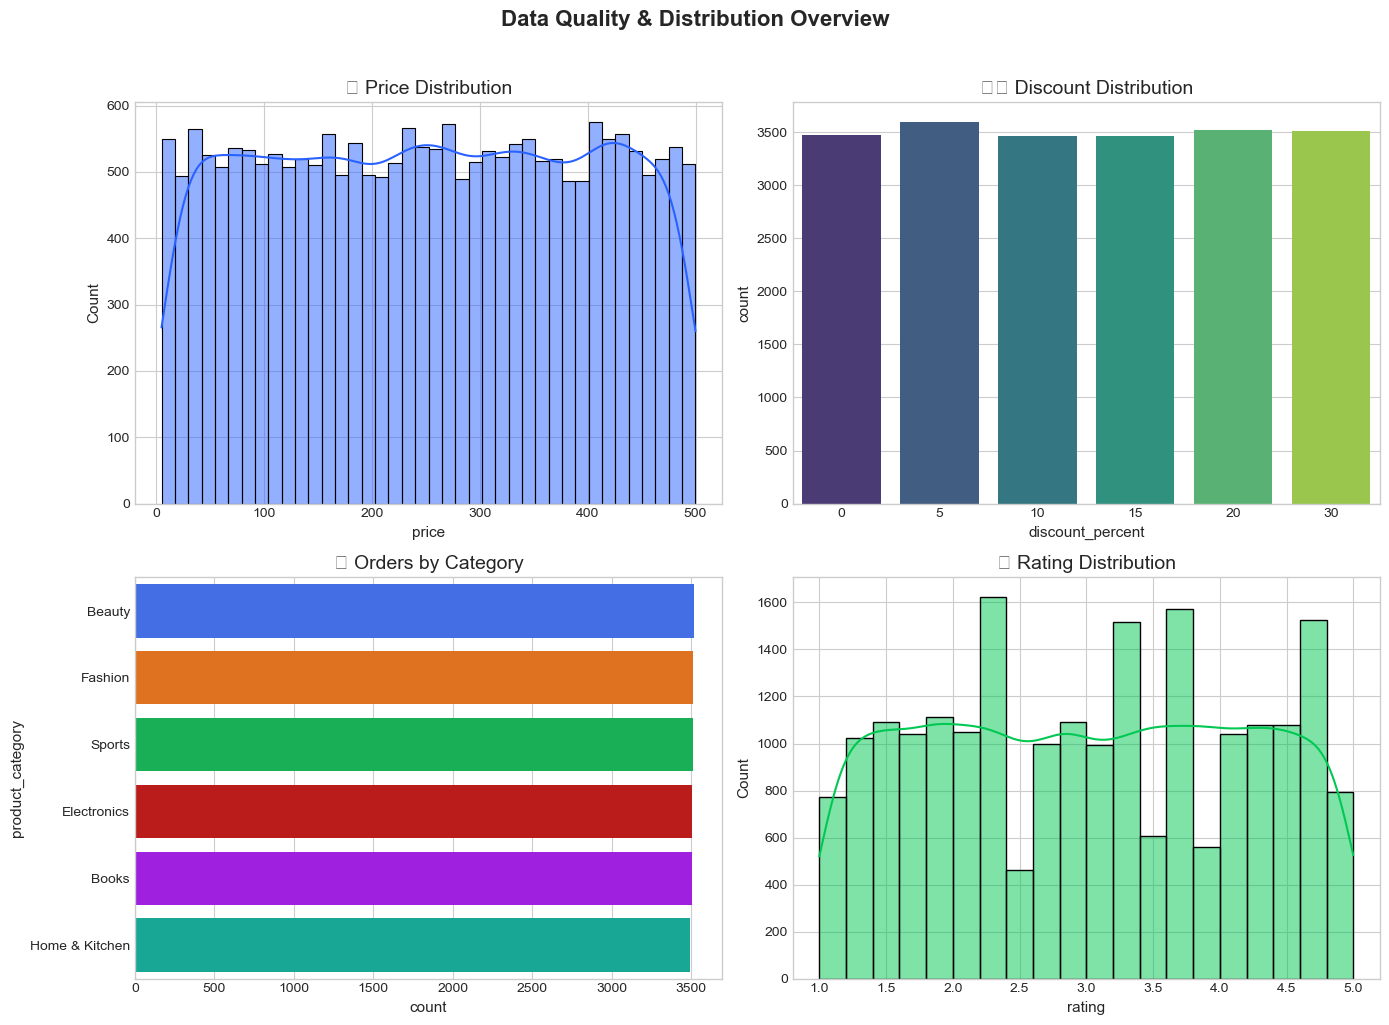

In [6]:
# ========================================
# DATA QUALITY VISUALIZATION
# ========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['price'], bins=40, kde=True, color=COLORS['primary'], ax=axes[0, 0])
axes[0, 0].set_title('💲 Price Distribution')

sns.countplot(data=df, x='discount_percent', palette='viridis', ax=axes[0, 1],
              order=sorted(df.discount_percent.unique()))
axes[0, 1].set_title('🏷️ Discount Distribution')

sns.countplot(data=df, y='product_category', palette=CAT_PALETTE, ax=axes[1, 0],
              order=df.product_category.value_counts().index)
axes[1, 0].set_title('📦 Orders by Category')

sns.histplot(df['rating'], bins=20, kde=True, color=COLORS['accent'], ax=axes[1, 1])
axes[1, 1].set_title('⭐ Rating Distribution')

plt.suptitle('Data Quality & Distribution Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,21030.000000,21030.000000,21030.000000,21030.000000,21030.000000,21030.000000,21030.000000,21030.000000,21030.000000
mean,16937.386163,2996.187399,252.642150,13.333571,3.014979,3.000309,247.865430,218.986622,660.207689
std,13041.269374,1154.091026,142.957485,9.865289,1.417979,1.156036,144.841149,127.146523,527.409897
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.600000,4.290000
25%,5985.250000,1997.250000,128.815000,5.000000,2.000000,2.000000,123.000000,110.202500,241.790000
50%,13872.500000,2994.000000,253.155000,10.000000,3.000000,3.000000,247.000000,216.385000,510.030000
75%,25703.250000,3996.000000,376.087500,20.000000,4.000000,4.000000,373.000000,322.947500,971.115000
max,49978.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.890000,2498.850000


In [8]:
df.get("product_category")

0              Books
1            Fashion
2             Sports
3              Books
4             Beauty
            ...     
49910         Beauty
49937    Electronics
49975    Electronics
49976        Fashion
49977          Books
Name: product_category, Length: 21030, dtype: object

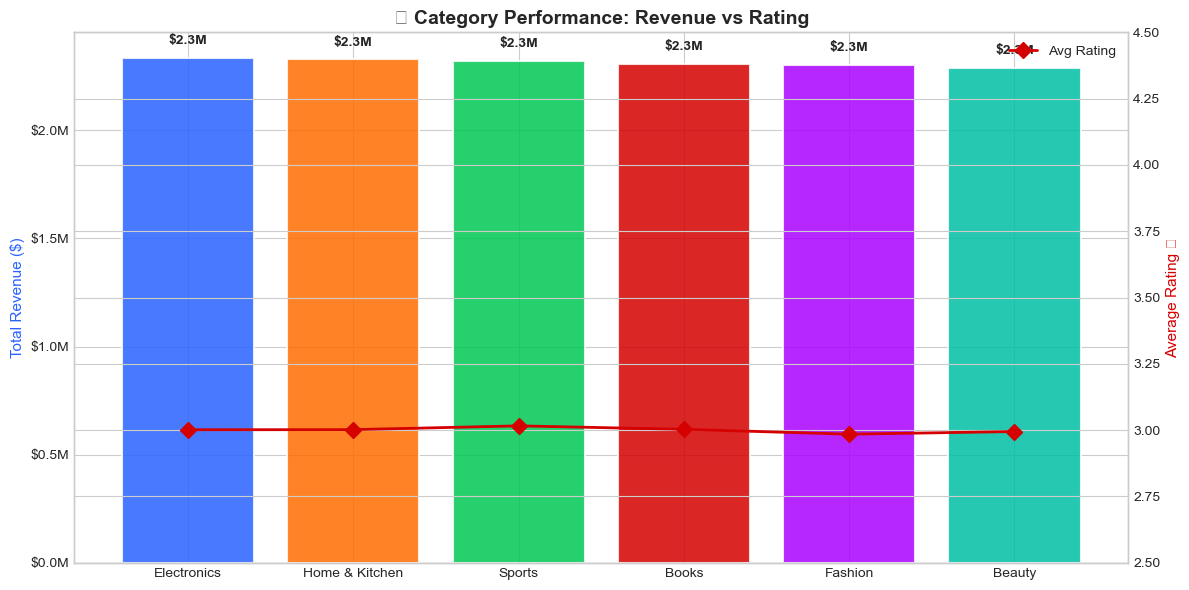

In [9]:
# ========================================
# PRODUCT CATEGORY PERFORMANCE
# ========================================
cat_stats = df.groupby('product_category').agg(
    revenue=('total_revenue', 'sum'), avg_rating=('rating', 'mean'),
    orders=('order_id', 'count'), avg_price=('price', 'mean')).sort_values('revenue', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))
bars = ax1.bar(cat_stats.index, cat_stats.revenue, color=CAT_PALETTE, alpha=0.85, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Total Revenue ($)', color=COLORS['primary'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

ax2 = ax1.twinx()
ax2.plot(cat_stats.index, cat_stats.avg_rating, 'D-', color=COLORS['danger'], markersize=8, linewidth=2, label='Avg Rating')
ax2.set_ylabel('Average Rating ⭐', color=COLORS['danger']); ax2.set_ylim(2.5, 4.5)

# Add revenue labels on bars
for bar, val in zip(bars, cat_stats.revenue):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000, f'${val/1e6:.1f}M',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('📦 Category Performance: Revenue vs Rating', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right'); plt.tight_layout(); plt.show()

In [10]:
beauty_df = df[df["product_category"] == "Beauty"]
beauty_df


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
14,15,2023-01-08,1051,Beauty,66.65,10,2,North America,Debit Card,4.6,262,59.99,119.98
21,22,2023-05-07,1599,Beauty,50.09,0,1,Europe,UPI,4.3,34,50.09,50.09
22,23,2023-02-18,1170,Beauty,362.40,15,2,North America,Debit Card,2.4,318,308.04,616.08
23,24,2023-01-21,4108,Beauty,72.05,20,2,Middle East,Debit Card,4.4,129,57.64,115.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49719,49720,2022-05-15,1578,Beauty,71.25,10,4,Europe,Wallet,2.7,339,64.12,256.48
49732,49733,2023-10-15,1693,Beauty,437.15,0,1,Europe,Credit Card,2.1,489,437.15,437.15
49795,49796,2023-02-26,4806,Beauty,153.79,20,1,North America,UPI,3.7,380,123.03,123.03
49822,49823,2022-08-19,4588,Beauty,384.54,20,5,Middle East,Cash on Delivery,1.8,80,307.63,1538.15


In [11]:
Home_Kitchen_df = df[df["product_category"] == "Home & Kitchen"]
Home_Kitchen_df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
13,14,2022-03-29,4925,Home & Kitchen,213.22,0,3,Europe,Credit Card,1.4,239,213.22,639.66
17,18,2022-05-11,3222,Home & Kitchen,156.95,30,3,Middle East,Cash on Delivery,2.9,354,109.86,329.58
18,19,2023-10-24,1968,Home & Kitchen,262.36,10,1,Asia,Wallet,4.6,473,236.12,236.12
20,21,2022-12-10,2734,Home & Kitchen,464.87,10,3,North America,Wallet,3.8,490,418.38,1255.14
43,44,2023-05-20,3082,Home & Kitchen,223.58,5,3,Middle East,Wallet,3.5,238,212.40,637.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49465,49466,2023-06-09,4850,Home & Kitchen,446.58,0,5,Middle East,Credit Card,4.6,389,446.58,2232.90
49473,49474,2022-03-16,2679,Home & Kitchen,290.74,10,4,Asia,Debit Card,4.8,232,261.67,1046.68
49577,49578,2023-07-01,3121,Home & Kitchen,225.78,0,4,Middle East,Wallet,4.7,422,225.78,903.12
49734,49735,2023-04-15,4320,Home & Kitchen,369.53,20,1,North America,Wallet,3.5,441,295.62,295.62


In [12]:
Electronics_df = df[df["product_category"] == "Electronics"]
Electronics_df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
10,11,2022-08-03,4878,Electronics,67.43,20,4,Europe,Debit Card,4.3,426,53.94,215.76
12,13,2023-04-04,3222,Electronics,89.81,0,3,Europe,UPI,3.6,151,89.81,269.43
15,16,2022-04-10,3344,Electronics,419.66,0,3,Middle East,Credit Card,2.7,46,419.66,1258.98
29,30,2022-01-22,4771,Electronics,239.79,15,5,North America,Credit Card,2.8,150,203.82,1019.10
33,34,2022-02-28,4053,Electronics,235.65,5,3,North America,Cash on Delivery,4.3,448,223.87,671.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49852,49853,2022-02-08,4593,Electronics,65.95,15,2,Europe,Cash on Delivery,5.0,138,56.06,112.12
49879,49880,2023-07-15,1788,Electronics,102.42,5,3,Middle East,UPI,2.4,74,97.30,291.90
49904,49905,2022-04-07,4777,Electronics,312.77,5,3,North America,Cash on Delivery,4.5,468,297.13,891.39
49937,49938,2022-03-30,1862,Electronics,304.55,30,5,North America,Cash on Delivery,4.7,107,213.18,1065.90


In [13]:
Books_df = df[df["product_category"] == "Books"]
Books_df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
8,9,2022-05-02,3262,Books,373.62,0,4,Asia,Wallet,2.8,497,373.62,1494.48
11,12,2022-11-27,3637,Books,150.19,0,1,North America,Cash on Delivery,4.4,279,150.19,150.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49871,49872,2023-09-27,1046,Books,97.29,10,5,Europe,Debit Card,2.4,402,87.56,437.80
49872,49873,2022-06-15,1499,Books,116.94,15,2,North America,Cash on Delivery,3.4,231,99.40,198.80
49873,49874,2022-07-22,3554,Books,435.48,5,3,Asia,UPI,4.7,175,413.71,1241.13
49891,49892,2022-08-23,4412,Books,63.92,30,1,Europe,Debit Card,3.3,81,44.74,44.74


In [14]:
Sports_df = df[df["product_category"] == "Sports"]
Sports_df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
5,6,2023-12-02,1777,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,808.86
9,10,2023-04-12,4174,Sports,134.81,15,2,Middle East,Cash on Delivery,2.0,25,114.59,229.18
16,17,2023-10-26,3011,Sports,391.09,5,3,Middle East,Credit Card,3.7,51,371.54,1114.62
27,28,2023-04-05,4557,Sports,191.67,10,5,Asia,Cash on Delivery,4.3,106,172.50,862.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49571,49572,2022-02-04,2384,Sports,401.64,0,3,Europe,Debit Card,3.6,170,401.64,1204.92
49576,49577,2022-07-12,3507,Sports,282.32,10,2,Asia,Credit Card,4.7,282,254.09,508.18
49702,49703,2023-08-05,4861,Sports,482.74,0,3,Middle East,Cash on Delivery,4.0,33,482.74,1448.22
49792,49793,2023-11-01,3832,Sports,283.06,5,4,Asia,Cash on Delivery,3.7,303,268.91,1075.64


In [15]:
Fashion_df = df[df["product_category"] == "Fashion"]
Fashion_df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
7,8,2023-09-07,3537,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.44
19,20,2022-11-05,3390,Fashion,428.24,30,3,Middle East,Wallet,1.2,331,299.77,899.31
25,26,2022-10-04,4272,Fashion,44.08,15,1,Europe,Debit Card,1.1,303,37.47,37.47
30,31,2022-09-10,1726,Fashion,256.57,20,2,North America,Credit Card,3.6,269,205.26,410.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49733,49734,2023-07-10,2387,Fashion,446.33,20,4,Europe,Credit Card,1.8,56,357.06,1428.24
49753,49754,2023-05-06,2705,Fashion,219.67,30,3,North America,UPI,2.4,404,153.77,461.31
49777,49778,2022-08-28,1621,Fashion,10.38,20,2,Middle East,UPI,4.8,153,8.30,16.60
49860,49861,2023-06-10,1641,Fashion,193.16,15,2,Europe,Credit Card,4.3,74,164.19,328.38


In [17]:
print(df.groupby("product_category")["total_revenue"].sum())


product_category
Beauty            2290094.75
Books             2308594.40
Electronics       2336230.67
Fashion           2300965.65
Home & Kitchen    2327872.79
Sports            2320409.43
Name: total_revenue, dtype: float64


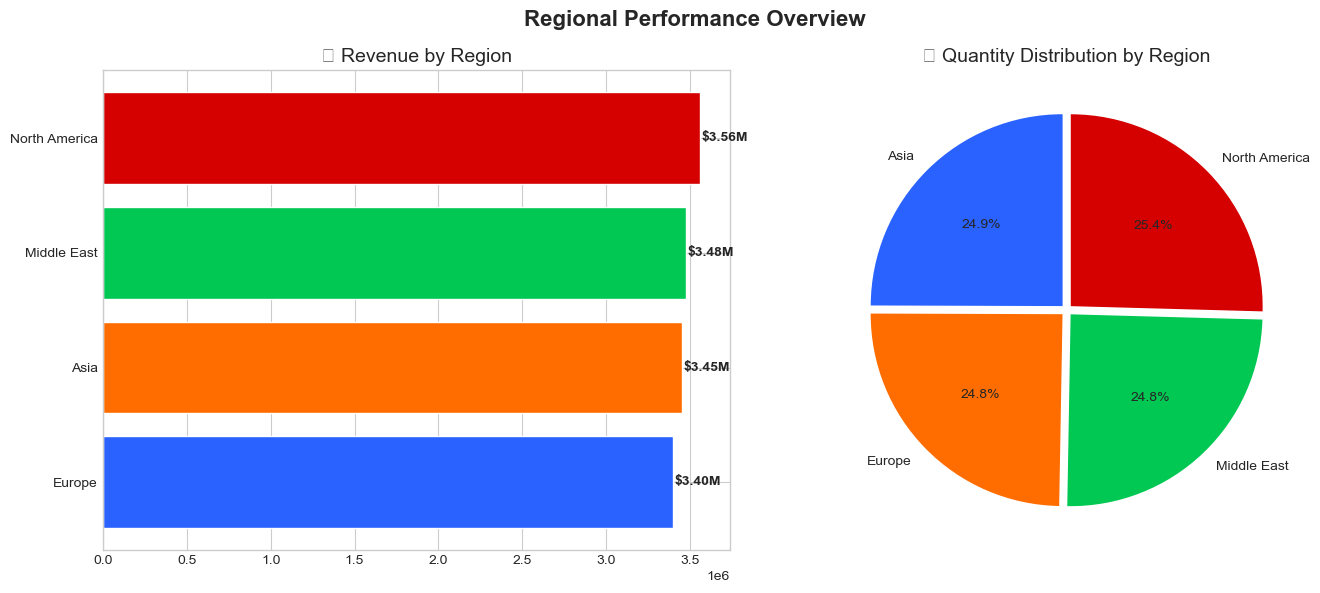

In [18]:
# ========================================
# REGIONAL ANALYSIS
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

region_rev = df.groupby('customer_region')['total_revenue'].sum().sort_values()
axes[0].barh(region_rev.index, region_rev.values, color=CAT_PALETTE[:len(region_rev)], edgecolor='white')
for i, v in enumerate(region_rev.values):
    axes[0].text(v + 10000, i, f'${v/1e6:.2f}M', va='center', fontweight='bold')
axes[0].set_title('🌍 Revenue by Region')

region_qty = df.groupby('customer_region')['quantity_sold'].sum()
axes[1].pie(region_qty, labels=region_qty.index, autopct='%1.1f%%', colors=CAT_PALETTE[:len(region_qty)],
            startangle=90, explode=[0.03]*len(region_qty), textprops={'fontsize': 10})
axes[1].set_title('📊 Quantity Distribution by Region')

plt.suptitle('Regional Performance Overview', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ========================================
# DISCOUNT EFFECTIVENESS & PAYMENT ANALYSIS
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Discount vs Revenue
disc_stats = df.groupby('discount_bin').agg(avg_rev=('total_revenue', 'mean'), avg_qty=('quantity_sold', 'mean')).reset_index()
sns.barplot(data=disc_stats, x='discount_bin', y='avg_rev', palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('💰 Avg Revenue by Discount Tier'); axes[0].set_xlabel('Discount Tier'); axes[0].set_ylabel('Avg Revenue ($)')

# ANOVA test: discount impact on revenue
groups = [df[df.discount_bin == b]['total_revenue'].values for b in df.discount_bin.cat.categories]
f_stat, p_val = stats.f_oneway(*groups)
sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
axes[0].annotate(f'ANOVA: F={f_stat:.1f}, p={p_val:.2e} {sig}', xy=(0.5, 0.95),
                 xycoords='axes fraction', ha='center', fontsize=9, fontstyle='italic',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Payment method revenue
pay_rev = df.groupby('payment_method')['total_revenue'].sum().sort_values()
axes[1].barh(pay_rev.index, pay_rev.values, color=CAT_PALETTE[:len(pay_rev)], edgecolor='white')
axes[1].set_title('💳 Revenue by Payment Method')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Payment by region (stacked)
pay_region = pd.crosstab(df.customer_region, df.payment_method, normalize='index') * 100
pay_region.plot(kind='bar', stacked=True, ax=axes[2], colormap='Set2', edgecolor='white')
axes[2].set_title('🌍 Payment Preferences by Region'); axes[2].set_ylabel('% Share')
axes[2].legend(title='Payment', bbox_to_anchor=(1.05, 1), fontsize=8); axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

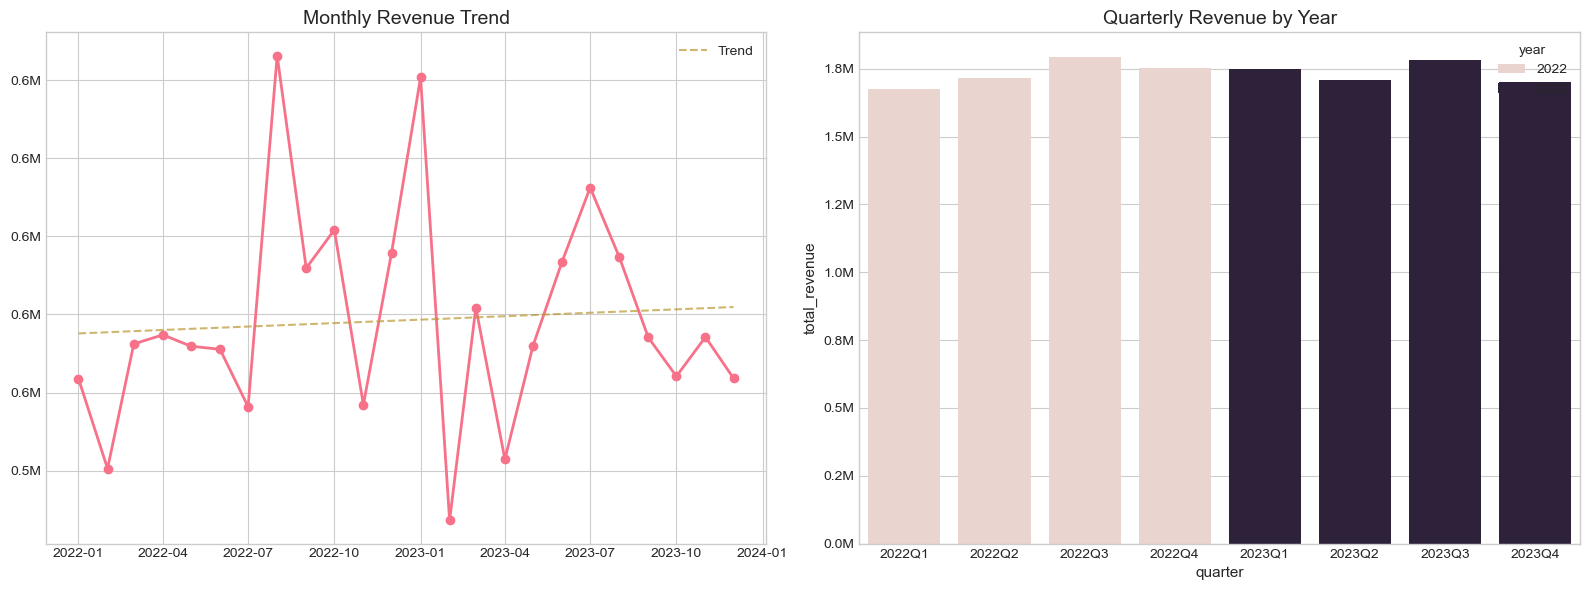

In [20]:
df = df.copy()

# ensure datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# year & quarter create (agar pehle se nahi hain)
df["year"] = df["order_date"].dt.year
df["quarter"] = df["order_date"].dt.to_period("Q").astype(str)

# ---------- Monthly Aggregation ----------
monthly = df.groupby(df["order_date"].dt.to_period("M")).agg(
    revenue=("total_revenue", "sum"),
    orders=("order_id", "count"),
    avg_order=("total_revenue", "mean")
).reset_index()

monthly["order_date"] = monthly["order_date"].dt.to_timestamp()

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Monthly revenue trend
axes[0].plot(monthly["order_date"], monthly["revenue"], linewidth=2, marker="o")

z = np.polyfit(range(len(monthly)), monthly["revenue"], 1)
axes[0].plot(monthly["order_date"], np.polyval(z, range(len(monthly))), "--", alpha=0.7, label="Trend")

axes[0].set_title("Monthly Revenue Trend")
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

# ---------- Quarterly comparison ----------
qtr = df.groupby(["year", "quarter"])["total_revenue"].sum().reset_index()

sns.barplot(data=qtr, x="quarter", y="total_revenue", hue="year", ax=axes[1])
axes[1].set_title("Quarterly Revenue by Year")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

plt.tight_layout()
plt.show()

In [ ]:
plt.scatter(file["rating"], file["total_revenue"], color="Orange")
plt.title("Rating vs Revenue")
plt.xlabel("Rating")
plt.ylabel("Revenue")
plt.show()


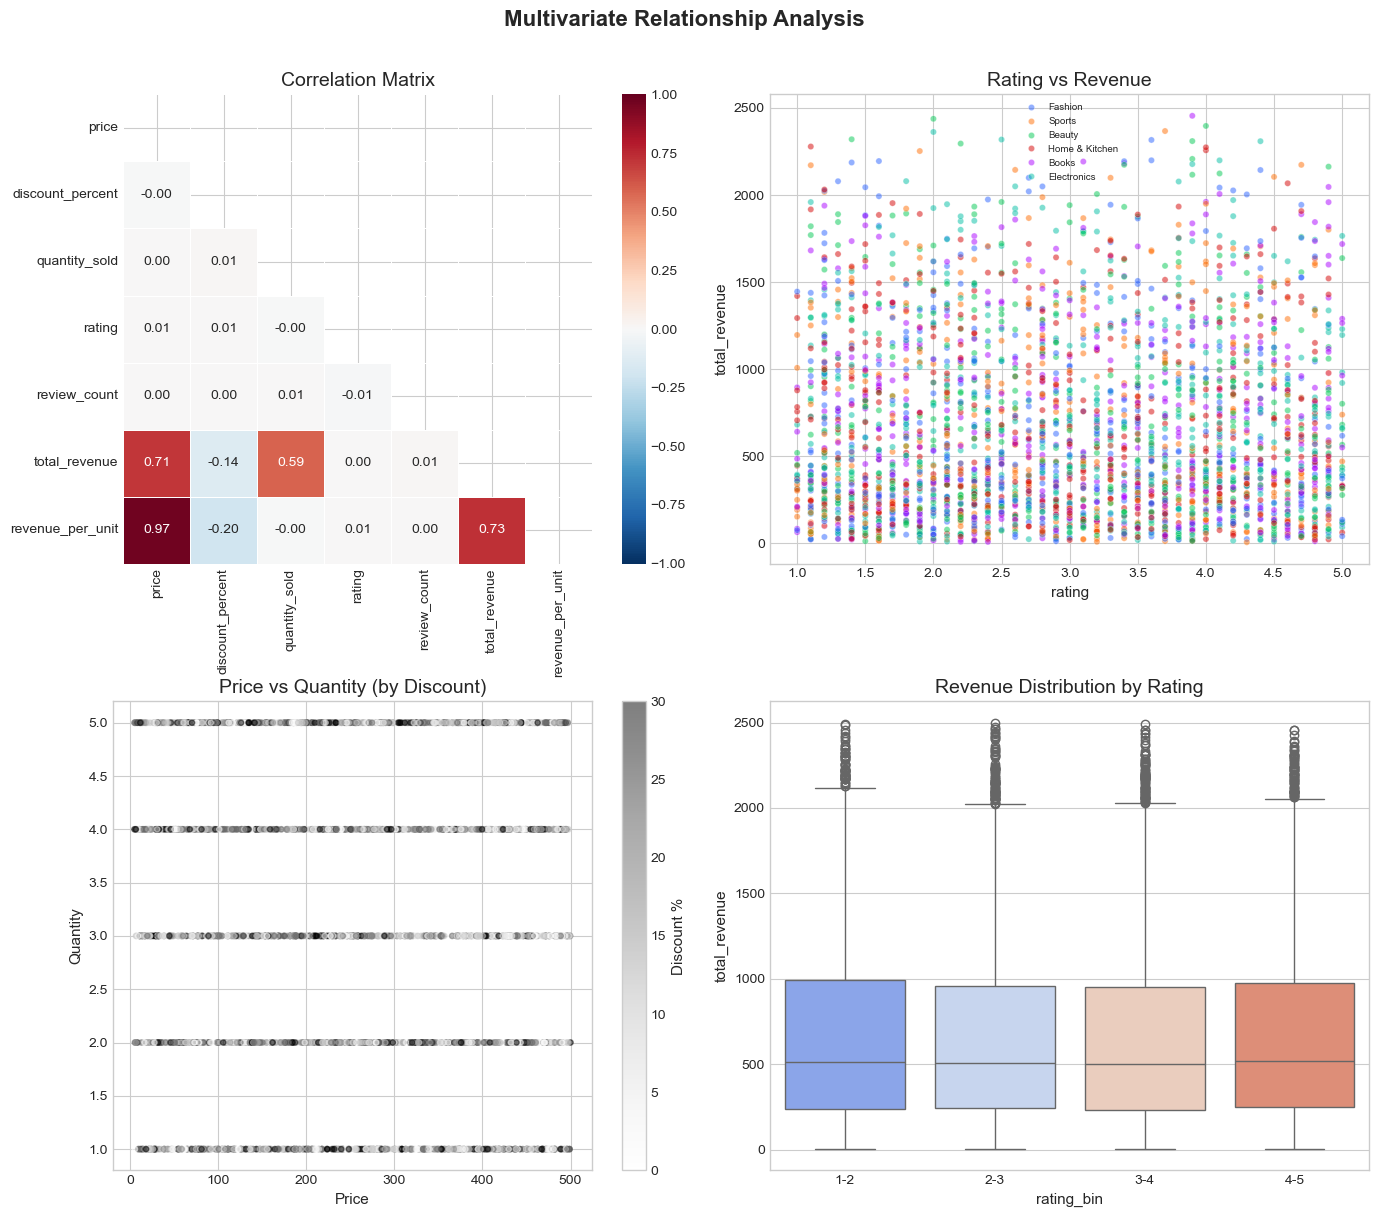

In [22]:
df = df.copy()

# -------- Ensure required columns exist --------
if "revenue_per_unit" not in df.columns:
    df["revenue_per_unit"] = df["total_revenue"] / df["quantity_sold"].replace(0, np.nan)

# sample once (efficient + consistent plots)
sample_df = df.sample(min(3000, len(df)), random_state=42)

# palette safe fallback
if "CAT_PALETTE" not in globals():
    CAT_PALETTE = "tab10"

# -------- Plot --------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Correlation heatmap
num_cols = [
    "price",
    "discount_percent",
    "quantity_sold",
    "rating",
    "review_count",
    "total_revenue",
    "revenue_per_unit"
]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=axes[0, 0],
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
axes[0, 0].set_title("Correlation Matrix")

# Rating vs Revenue
sns.scatterplot(
    data=sample_df,
    x="rating",
    y="total_revenue",
    hue="product_category",
    alpha=0.5,
    ax=axes[0, 1],
    palette=CAT_PALETTE,
    s=20
)
axes[0, 1].set_title("Rating vs Revenue")
axes[0, 1].legend(fontsize=7)

# Price vs Quantity (colored by discount)
sc = axes[1, 0].scatter(
    sample_df["price"],
    sample_df["quantity_sold"],
    c=sample_df["discount_percent"],
    alpha=0.5,
    s=15
)
plt.colorbar(sc, ax=axes[1, 0], label="Discount %")
axes[1, 0].set_title("Price vs Quantity (by Discount)")
axes[1, 0].set_xlabel("Price")
axes[1, 0].set_ylabel("Quantity")

# Revenue by rating bins
df["rating_bin"] = pd.cut(
    df["rating"],
    bins=[0, 2, 3, 4, 5],
    labels=["1-2", "2-3", "3-4", "4-5"]
)

sns.boxplot(
    data=df,
    x="rating_bin",
    y="total_revenue",
    palette="coolwarm",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Revenue Distribution by Rating")

plt.suptitle("Multivariate Relationship Analysis", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

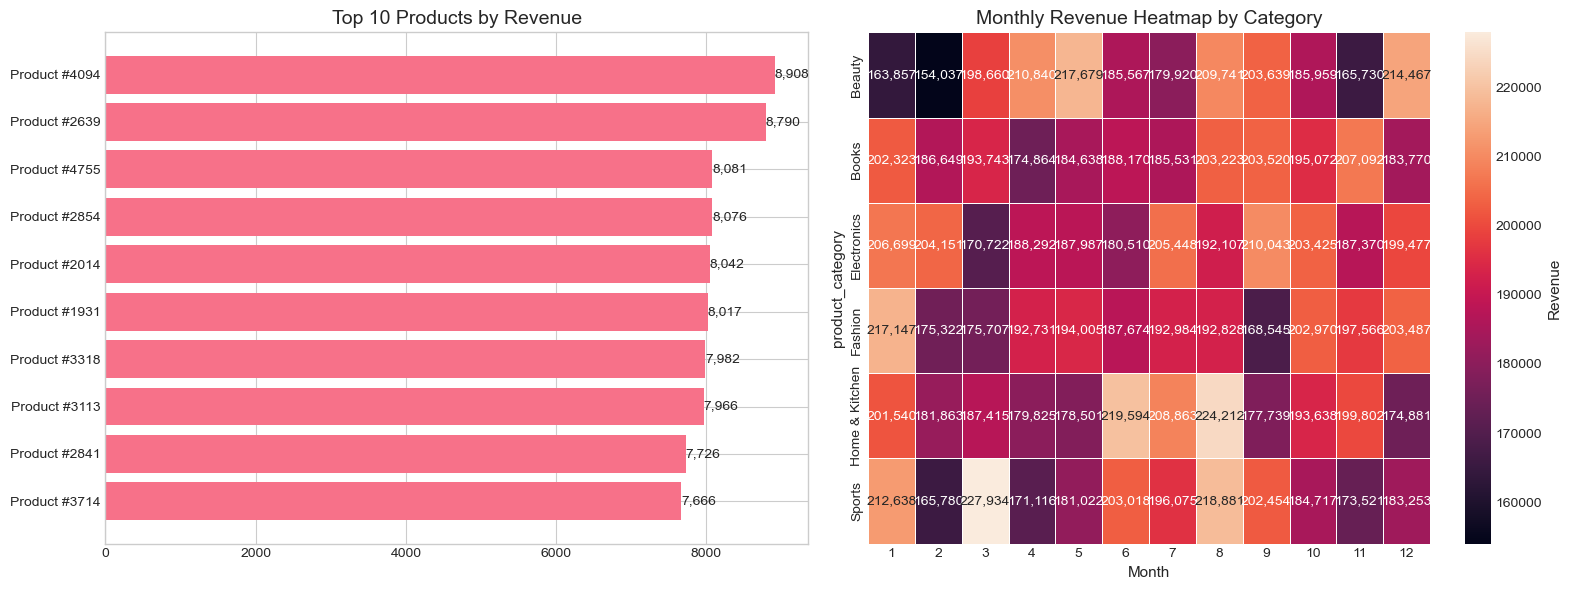

In [24]:
df = df.copy()

# ----- ensure month column -----
if "month" not in df.columns:
    df["order_date"] = pd.to_datetime(df["order_date"])
    df["month"] = df["order_date"].dt.month

# ----- safe color fallback -----
PRIMARY_COLOR = "#4e79a7"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== Top 10 products by revenue =====
top_products = df.groupby("product_id")["total_revenue"].sum().nlargest(10)

axes[0].barh(range(len(top_products)), top_products.values)
axes[0].set_yticks(range(len(top_products)))
axes[0].set_yticklabels([f"Product #{pid}" for pid in top_products.index])

for i, v in enumerate(top_products.values):
    axes[0].text(v, i, f"{v:,.0f}", va="center")

axes[0].set_title("Top 10 Products by Revenue")
axes[0].invert_yaxis()

# ===== Seasonal heatmap =====
pivot = df.pivot_table(
    values="total_revenue",
    index="product_category",
    columns="month",
    aggfunc="sum"
)

sns.heatmap(
    pivot,
    annot=True,
    fmt=",.0f",
    ax=axes[1],
    linewidths=0.5,
    cbar_kws={"label": "Revenue"}
)

axes[1].set_title("Monthly Revenue Heatmap by Category")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()